In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
import random

In [6]:
X,y= make_classification(n_features=5,n_redundant=0,n_informative=5,n_clusters_per_class=1)

In [10]:
df= pd.DataFrame(X, columns= ['col1', 'col2', 'col3', 'col4', 'col5'])
df['target']= y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,1.706893,-2.497522,0.258514,0.068469,-1.509600,0
1,1.771355,-1.330189,0.334928,0.781984,-0.345786,0
2,2.389664,-0.321624,2.182837,2.636385,0.709702,0
3,1.014894,-2.734852,-0.788420,-1.373457,-2.812899,0
4,-0.576911,-1.780471,1.788694,1.188669,-2.154064,0


In [12]:
# fun for row sampling

In [14]:
def sample_rows(df, percent):
    return df.sample(int(percent*df.shape[0]), replace= True)

In [18]:
# fun for feature sampling
def sample_features(df,percent):
    cols= random.sample(df.columns.tolist()[:-1], int(percent*(df.shape[1]-1)))
    new_df= df[cols]
    new_df['target']= df['target']
    return new_df

In [20]:
# combination sampling

In [22]:
def combined_sampling(df, row_percent, col_percent):
    new_df= sample_rows(df, row_percent)
    return sample_features(new_df, col_percent)

In [30]:
df1 = combined_sampling(df,0.5,0.5)
df2 = combined_sampling(df,0.5,0.5)
df3 = combined_sampling(df,0.5,0.5)

C:\Users\Hp\AppData\Local\Temp\ipykernel_18404\1089507109.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target']= df['target']
C:\Users\Hp\AppData\Local\Temp\ipykernel_18404\1089507109.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target']= df['target']
C:\Users\Hp\AppData\Local\Temp\ipykernel_18404\1089507109.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats i

In [32]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col4', 'col3', 'target'], dtype='object')
Index(['col3', 'col1', 'target'], dtype='object')
Index(['col2', 'col1', 'target'], dtype='object')


In [34]:
from sklearn.tree import DecisionTreeClassifier
clf1= DecisionTreeClassifier()
clf2= DecisionTreeClassifier()
clf3= DecisionTreeClassifier()
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

DecisionTreeClassifier()

In [36]:
from sklearn.tree import plot_tree

[Text(0.4583333333333333, 0.9166666666666666, 'x[1] <= -0.315\ngini = 0.5\nsamples = 50\nvalue = [25, 25]'),
 Text(0.25, 0.75, 'x[0] <= 0.496\ngini = 0.105\nsamples = 18\nvalue = [1, 17]'),
 Text(0.35416666666666663, 0.8333333333333333, 'True  '),
 Text(0.16666666666666666, 0.5833333333333334, 'x[0] <= 0.295\ngini = 0.375\nsamples = 4\nvalue = [1, 3]'),
 Text(0.08333333333333333, 0.4166666666666667, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.25, 0.4166666666666667, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.3333333333333333, 0.5833333333333334, 'gini = 0.0\nsamples = 14\nvalue = [0, 14]'),
 Text(0.6666666666666666, 0.75, 'x[0] <= 0.288\ngini = 0.375\nsamples = 32\nvalue = [24, 8]'),
 Text(0.5625, 0.8333333333333333, '  False'),
 Text(0.5, 0.5833333333333334, 'x[0] <= -0.059\ngini = 0.42\nsamples = 10\nvalue = [3, 7]'),
 Text(0.4166666666666667, 0.4166666666666667, 'x[1] <= 0.056\ngini = 0.5\nsamples = 6\nvalue = [3, 3]'),
 Text(0.3333333333333333, 0.25, 'gini = 0.0\ns

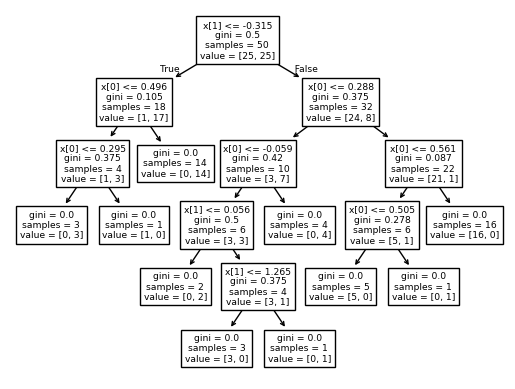

In [38]:
plot_tree(clf1)